# ✈️ Flight Price Intelligence

## Project Introduction

This project focuses on analyzing flight pricing data to identify the key factors that influence airline ticket prices.

The analysis covers flight details such as airline, source, destination, route, departure time, arrival time, duration, number of stops, and ticket price.

The project follows an end-to-end data analytics workflow:

**Excel → Python → SQL → Power BI**

### Project Objectives

- Analyze flight price patterns across different airlines and routes.
- Understand the impact of stops and flight duration on ticket prices.
- Explore travel date and departure-time patterns.
- Identify high-priced and low-priced flight segments.
- Generate meaningful business insights from the data.
- Build an interactive Power BI dashboard for visualization and decision-making.

### Tools & Technologies

- **Excel** – Data preparation and transformation
- **Python** – Data cleaning, analysis and exploratory data analysis
- **SQL** – Data querying and business analysis
- **Power BI** – Interactive dashboard and visualization


## 1. Import Required Libraries


In [ ]:
!pip install pandas
!pip isntall numpy
!pip install matplotlib
!pip install seaborn
!pip install plotly

ERROR: unknown command "isntall" - maybe you meant "install"


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [93]:
data = pd.read_csv("flight_price_data.csv")

In [94]:
df = data.copy()
df.head(5)

,Airline,Day_of_Journey,month_of_Journey,year_of_Journey,Source,Destination,Route,Dep_hour,Dep_min,Arrival_Time,duration_hour,duration_min,Total_Stops,Additional_Info,Price,Unnamed: 15
0,IndiGo,24,3,2019,Banglore,New Delhi,BLR → DEL,22,20,1:10,2,50.0,non-stop,No info,3897,NaN
1,Air India,1,5,2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,5,50,1:15,7,25.0,2 stops,No info,7662,NaN
2,Jet Airways,9,6,2019,Delhi,Cochin,DEL → LKO → BOM → COK,9,25,4:25,19,NaN,2 stops,No info,13882,NaN
3,IndiGo,12,5,2019,Kolkata,Banglore,CCU → NAG → BLR,18,5,11:30,5,25.0,1 stop,No info,6218,NaN
4,IndiGo,1,3,2019,Banglore,New Delhi,BLR → NAG → DEL,16,50,9:35,4,45.0,1 stop,No info,13302,NaN


In [95]:
df.columns

Index(['Airline', 'Day_of_Journey', 'month_of_Journey', 'year_of_Journey',
       'Source', 'Destination', 'Route', 'Dep_hour', 'Dep_min', 'Arrival_Time',
       'duration_hour', 'duration_min', 'Total_Stops', 'Additional_Info',
       'Price', 'Unnamed: 15'],
      dtype='object')

In [96]:
df.size


170928

In [97]:
df.shape

(10683, 16)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Airline           10683 non-null  object 
 1   Day_of_Journey    10683 non-null  int64  
 2   month_of_Journey  10683 non-null  int64  
 3   year_of_Journey   10683 non-null  int64  
 4   Source            10683 non-null  object 
 5   Destination       10683 non-null  object 
 6   Route             10682 non-null  object 
 7   Dep_hour          10683 non-null  int64  
 8   Dep_min           10683 non-null  int64  
 9   Arrival_Time      10683 non-null  object 
 10  duration_hour     10683 non-null  object 
 11  duration_min      9651 non-null   float64
 12  Total_Stops       10682 non-null  object 
 13  Additional_Info   10683 non-null  object 
 14  Price             10683 non-null  int64  
 15  Unnamed: 15       0 non-null      float64
dtypes: float64(2), int64(6), object(8)
memor

# check null value

In [98]:
df.isnull().sum()

,0
Airline,0
Day_of_Journey,0
month_of_Journey,0
year_of_Journey,0
Source,0
Destination,0
Route,1
Dep_hour,0
Dep_min,0
Arrival_Time,0


In [99]:
df.columns = df.columns.str.lower()

In [100]:
df.columns

Index(['airline', 'day_of_journey', 'month_of_journey', 'year_of_journey',
       'source', 'destination', 'route', 'dep_hour', 'dep_min', 'arrival_time',
       'duration_hour', 'duration_min', 'total_stops', 'additional_info',
       'price', 'unnamed: 15'],
      dtype='object')

In [101]:
df

,airline,day_of_journey,month_of_journey,year_of_journey,source,destination,route,dep_hour,dep_min,arrival_time,duration_hour,duration_min,total_stops,additional_info,price,unnamed: 15
0,IndiGo,24,3,2019,Banglore,New Delhi,BLR → DEL,22,20,1:10,2,50.0,non-stop,No info,3897,NaN
1,Air India,1,5,2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,5,50,1:15,7,25.0,2 stops,No info,7662,NaN
2,Jet Airways,9,6,2019,Delhi,Cochin,DEL → LKO → BOM → COK,9,25,4:25,19,NaN,2 stops,No info,13882,NaN
3,IndiGo,12,5,2019,Kolkata,Banglore,CCU → NAG → BLR,18,5,11:30,5,25.0,1 stop,No info,6218,NaN
4,IndiGo,1,3,2019,Banglore,New Delhi,BLR → NAG → DEL,16,50,9:35,4,45.0,1 stop,No info,13302,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9,4,2019,Kolkata,Banglore,CCU → BLR,19,55,10:25,2,30.0,non-stop,No info,4107,NaN
10679,Air India,27,4,2019,Kolkata,Banglore,CCU → BLR,20,45,11:20,2,35.0,non-stop,No info,4145,NaN
10680,Jet Airways,27,4,2019,Banglore,Delhi,BLR → DEL,8,20,11:20,3,NaN,non-stop,No info,7229,NaN
10681,Vistara,1,3,2019,Banglore,New Delhi,BLR → DEL,11,30,2:10,2,40.0,non-stop,No info,12648,NaN


In [102]:
df.columns

Index(['airline', 'day_of_journey', 'month_of_journey', 'year_of_journey',
       'source', 'destination', 'route', 'dep_hour', 'dep_min', 'arrival_time',
       'duration_hour', 'duration_min', 'total_stops', 'additional_info',
       'price', 'unnamed: 15'],
      dtype='object')

In [103]:
df.drop(columns="unnamed: 15", inplace=True)

In [104]:
df.columns

Index(['airline', 'day_of_journey', 'month_of_journey', 'year_of_journey',
       'source', 'destination', 'route', 'dep_hour', 'dep_min', 'arrival_time',
       'duration_hour', 'duration_min', 'total_stops', 'additional_info',
       'price'],
      dtype='object')

In [105]:
df.isnull().sum()

,0
airline,0
day_of_journey,0
month_of_journey,0
year_of_journey,0
source,0
destination,0
route,1
dep_hour,0
dep_min,0
arrival_time,0


In [106]:
df.duration_min

,duration_min
0,50.0
1,25.0
2,NaN
3,25.0
4,45.0
...,...
10678,30.0
10679,35.0
10680,NaN
10681,40.0


In [107]:
df[["duration_hour","duration_min"]]

,duration_hour,duration_min
0,2,50.0
1,7,25.0
2,19,NaN
3,5,25.0
4,4,45.0
...,...,...
10678,2,30.0
10679,2,35.0
10680,3,NaN
10681,2,40.0


In [108]:
df["duration_min"] = df["duration_min"].fillna(0)

In [109]:
df.isnull().sum()

,0
airline,0
day_of_journey,0
month_of_journey,0
year_of_journey,0
source,0
destination,0
route,1
dep_hour,0
dep_min,0
arrival_time,0


In [110]:
df[df["route"].isnull()]


,airline,day_of_journey,month_of_journey,year_of_journey,source,destination,route,dep_hour,dep_min,arrival_time,duration_hour,duration_min,total_stops,additional_info,price
9039,Air India,6,5,2019,Delhi,Cochin,NaN,9,45,9:25,23,40.0,NaN,No info,7480


In [111]:
# DEL → COK

df["route"]=df["route"].fillna("DEL → COK")

In [112]:
df.isnull().sum()

,0
airline,0
day_of_journey,0
month_of_journey,0
year_of_journey,0
source,0
destination,0
route,0
dep_hour,0
dep_min,0
arrival_time,0


In [113]:
df["total_stops"].mode()

,total_stops
0,1 stop


In [114]:
df["total_stops"] = df["total_stops"].fillna("1 stop")

In [115]:
df.isna().sum()

,0
airline,0
day_of_journey,0
month_of_journey,0
year_of_journey,0
source,0
destination,0
route,0
dep_hour,0
dep_min,0
arrival_time,0


In [116]:
category_column=[feature for feature in df.columns if df[feature].dtype == "O"]
numerical_column = [feature for feature in df.columns if df[feature].dtype != "O"]



In [117]:
category_column

['airline',
 'source',
 'destination',
 'route',
 'arrival_time',
 'duration_hour',
 'total_stops',
 'additional_info']

In [118]:
numerical_column

['day_of_journey',
 'month_of_journey',
 'year_of_journey',
 'dep_hour',
 'dep_min',
 'duration_min',
 'price']

In [119]:
df[df.duplicated()]

,airline,day_of_journey,month_of_journey,year_of_journey,source,destination,route,dep_hour,dep_min,arrival_time,duration_hour,duration_min,total_stops,additional_info,price
683,Jet Airways,1,6,2019,Delhi,Cochin,DEL → NAG → BOM → COK,14,35,4:25,13,50.0,2 stops,No info,13376
1061,Air India,21,5,2019,Delhi,Cochin,DEL → GOI → BOM → COK,22,0,7:15,21,15.0,2 stops,No info,10231
1348,Air India,18,5,2019,Delhi,Cochin,DEL → HYD → BOM → COK,17,15,7:15,26,0.0,2 stops,No info,12392
1418,Jet Airways,6,6,2019,Delhi,Cochin,DEL → JAI → BOM → COK,5,30,4:25,22,55.0,2 stops,In-flight meal not included,10368
1674,IndiGo,24,3,2019,Banglore,New Delhi,BLR → DEL,18,25,9:20,2,55.0,non-stop,No info,7303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10594,Jet Airways,27,6,2019,Delhi,Cochin,DEL → AMD → BOM → COK,23,5,12:35,13,30.0,2 stops,No info,12819
10616,Jet Airways,1,6,2019,Delhi,Cochin,DEL → JAI → BOM → COK,9,40,12:35,26,55.0,2 stops,No info,13014
10634,Jet Airways,6,6,2019,Delhi,Cochin,DEL → JAI → BOM → COK,9,40,12:35,26,55.0,2 stops,In-flight meal not included,11733
10672,Jet Airways,27,6,2019,Delhi,Cochin,DEL → AMD → BOM → COK,23,5,7:00,19,55.0,2 stops,In-flight meal not included,11150


In [56]:
category_column


['airline',
 'source',
 'destination',
 'route',
 'arrival_time',
 'duration_hour',
 'total_stops',
 'additional_info']

In [120]:
df["arrival_time"].unique()

array(['1:10', '1:15', '4:25', '11:30', '9:35', '11:25', '10:25', '5:05',
       '7:15', '11:00', '10:55', '1:55', '9:20', '7:50', '12:35', '7:20',
       '1:20', '6:50', '9:50', '8:15', '3:35', '12:55', '11:15', '9:00',
       '8:20', '4:45', '7:00', '6:10', '3:15', '8:35', '11:05', '2:15',
       '12:15', '2:45', '12:00', '11:55', '1:30', '9:25', '3:25', '8:30',
       '10:05', '2:30', '7:55', '10:35', '4:40', '7:25', '8:45', '2:25',
       '10:30', '11:20', '7:40', '10:50', '2:35', '8:55', '9:05', '1:35',
       '9:40', '11:10', '5:50', '7:45', '4:10', '11:35', '8:00', '12:40',
       '9:45', '6:15', '4:15', '9:10', '6:05', '10:00', '3:30', '8:50',
       '7:35', '10:15', '12:45', '2:20', '11:50', '6:30', '8:05', '10:20',
       '10:10', '1:00', '12:20', '8:25', '10:45', '2:05', '12:05', '4:20',
       '7:05', '7:10', '4:05', '5:55', '5:25', '12:30', '11:40', '12:50',
       '1:45', '9:15', '5:35', '10:40', '1:25', '9:55', '6:35', '12:10',
       '2:00', '5:15', '11:45', '12:25', '6

In [121]:
df[~df["arrival_time"].str.isnumeric()]

,airline,day_of_journey,month_of_journey,year_of_journey,source,destination,route,dep_hour,dep_min,arrival_time,duration_hour,duration_min,total_stops,additional_info,price
0,IndiGo,24,3,2019,Banglore,New Delhi,BLR → DEL,22,20,1:10,2,50.0,non-stop,No info,3897
1,Air India,1,5,2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,5,50,1:15,7,25.0,2 stops,No info,7662
2,Jet Airways,9,6,2019,Delhi,Cochin,DEL → LKO → BOM → COK,9,25,4:25,19,0.0,2 stops,No info,13882
3,IndiGo,12,5,2019,Kolkata,Banglore,CCU → NAG → BLR,18,5,11:30,5,25.0,1 stop,No info,6218
4,IndiGo,1,3,2019,Banglore,New Delhi,BLR → NAG → DEL,16,50,9:35,4,45.0,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9,4,2019,Kolkata,Banglore,CCU → BLR,19,55,10:25,2,30.0,non-stop,No info,4107
10679,Air India,27,4,2019,Kolkata,Banglore,CCU → BLR,20,45,11:20,2,35.0,non-stop,No info,4145
10680,Jet Airways,27,4,2019,Banglore,Delhi,BLR → DEL,8,20,11:20,3,0.0,non-stop,No info,7229
10681,Vistara,1,3,2019,Banglore,New Delhi,BLR → DEL,11,30,2:10,2,40.0,non-stop,No info,12648


In [122]:
df["arrival_hour"] = df["arrival_time"].str.split(":").str[0]

In [123]:
df["arrival_min"] = df["arrival_time"].str.split(":").str[1]


In [124]:
df


,airline,day_of_journey,month_of_journey,year_of_journey,source,destination,route,dep_hour,dep_min,arrival_time,duration_hour,duration_min,total_stops,additional_info,price,arrival_hour,arrival_min
0,IndiGo,24,3,2019,Banglore,New Delhi,BLR → DEL,22,20,1:10,2,50.0,non-stop,No info,3897,1,10
1,Air India,1,5,2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,5,50,1:15,7,25.0,2 stops,No info,7662,1,15
2,Jet Airways,9,6,2019,Delhi,Cochin,DEL → LKO → BOM → COK,9,25,4:25,19,0.0,2 stops,No info,13882,4,25
3,IndiGo,12,5,2019,Kolkata,Banglore,CCU → NAG → BLR,18,5,11:30,5,25.0,1 stop,No info,6218,11,30
4,IndiGo,1,3,2019,Banglore,New Delhi,BLR → NAG → DEL,16,50,9:35,4,45.0,1 stop,No info,13302,9,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9,4,2019,Kolkata,Banglore,CCU → BLR,19,55,10:25,2,30.0,non-stop,No info,4107,10,25
10679,Air India,27,4,2019,Kolkata,Banglore,CCU → BLR,20,45,11:20,2,35.0,non-stop,No info,4145,11,20
10680,Jet Airways,27,4,2019,Banglore,Delhi,BLR → DEL,8,20,11:20,3,0.0,non-stop,No info,7229,11,20
10681,Vistara,1,3,2019,Banglore,New Delhi,BLR → DEL,11,30,2:10,2,40.0,non-stop,No info,12648,2,10


In [125]:
df.drop(columns="arrival_time",inplace=True,axis=1)

In [126]:
df["arrival_hour"] =df["arrival_hour"].astype(int)
df["arrival_min"] =df["arrival_min"].astype(int)


In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   airline           10683 non-null  object 
 1   day_of_journey    10683 non-null  int64  
 2   month_of_journey  10683 non-null  int64  
 3   year_of_journey   10683 non-null  int64  
 4   source            10683 non-null  object 
 5   destination       10683 non-null  object 
 6   route             10683 non-null  object 
 7   dep_hour          10683 non-null  int64  
 8   dep_min           10683 non-null  int64  
 9   duration_hour     10683 non-null  object 
 10  duration_min      10683 non-null  float64
 11  total_stops       10683 non-null  object 
 12  additional_info   10683 non-null  object 
 13  price             10683 non-null  int64  
 14  arrival_hour      10683 non-null  int64  
 15  arrival_min       10683 non-null  int64  
dtypes: float64(1), int64(8), object(7)
memor

In [128]:
df["duration_min"] = df["duration_min"].astype(int)

In [129]:
df[~df["duration_hour"].str.isnumeric()]

,airline,day_of_journey,month_of_journey,year_of_journey,source,destination,route,dep_hour,dep_min,duration_hour,duration_min,total_stops,additional_info,price,arrival_hour,arrival_min
6474,Air India,6,3,2019,Mumbai,Hyderabad,BOM → GOI → PNQ → HYD,16,50,5m,0,2 stops,No info,17327,4,55


In [130]:
df["duration_hour"]= df["duration_hour"].str.replace("m","")

In [131]:
df["duration_hour"] = df["duration_hour"].astype(int)

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   airline           10683 non-null  object
 1   day_of_journey    10683 non-null  int64 
 2   month_of_journey  10683 non-null  int64 
 3   year_of_journey   10683 non-null  int64 
 4   source            10683 non-null  object
 5   destination       10683 non-null  object
 6   route             10683 non-null  object
 7   dep_hour          10683 non-null  int64 
 8   dep_min           10683 non-null  int64 
 9   duration_hour     10683 non-null  int64 
 10  duration_min      10683 non-null  int64 
 11  total_stops       10683 non-null  object
 12  additional_info   10683 non-null  object
 13  price             10683 non-null  int64 
 14  arrival_hour      10683 non-null  int64 
 15  arrival_min       10683 non-null  int64 
dtypes: int64(10), object(6)
memory usage: 1.3+ MB


In [132]:
df["total_stops"].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [133]:
df["total_stops"] = df["total_stops"].map({"non-stop":0,"2 stops":2,"1 stop":1 , "3 stops":3,"4 stops": 4})

In [135]:
df["total_stops"].unique()

array([0, 2, 1, 3, 4])

In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   airline           10683 non-null  object
 1   day_of_journey    10683 non-null  int64 
 2   month_of_journey  10683 non-null  int64 
 3   year_of_journey   10683 non-null  int64 
 4   source            10683 non-null  object
 5   destination       10683 non-null  object
 6   route             10683 non-null  object
 7   dep_hour          10683 non-null  int64 
 8   dep_min           10683 non-null  int64 
 9   duration_hour     10683 non-null  int64 
 10  duration_min      10683 non-null  int64 
 11  total_stops       10683 non-null  int64 
 12  additional_info   10683 non-null  object
 13  price             10683 non-null  int64 
 14  arrival_hour      10683 non-null  int64 
 15  arrival_min       10683 non-null  int64 
dtypes: int64(11), object(5)
memory usage: 1.3+ MB


In [138]:
cat_col = [feature for feature in df.columns if df[feature].dtype == "O"]
num_col = [feature for feature in df.columns if df[feature].dtype != "O"]

In [139]:
cat_col

['airline', 'source', 'destination', 'route', 'additional_info']

In [140]:
num_col

['day_of_journey',
 'month_of_journey',
 'year_of_journey',
 'dep_hour',
 'dep_min',
 'duration_hour',
 'duration_min',
 'total_stops',
 'price',
 'arrival_hour',
 'arrival_min']

In [141]:
df.airline.unique()

array(['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet',
       'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia',
       'Vistara Premium economy', 'Jet Airways Business',
       'Multiple carriers Premium economy', 'Trujet'], dtype=object)

In [142]:
df.airline.nunique()

12

In [143]:
df.source.unique()
df.source.nunique()

5

In [144]:
df.destination.unique()
df.destination.nunique()

6

In [145]:
df.duration_hour

,duration_hour
0,2
1,7
2,19
3,5
4,4
...,...
10678,2
10679,2
10680,3
10681,2


In [146]:
df.head(5)

,airline,day_of_journey,month_of_journey,year_of_journey,source,destination,route,dep_hour,dep_min,duration_hour,duration_min,total_stops,additional_info,price,arrival_hour,arrival_min
0,IndiGo,24,3,2019,Banglore,New Delhi,BLR → DEL,22,20,2,50,0,No info,3897,1,10
1,Air India,1,5,2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,5,50,7,25,2,No info,7662,1,15
2,Jet Airways,9,6,2019,Delhi,Cochin,DEL → LKO → BOM → COK,9,25,19,0,2,No info,13882,4,25
3,IndiGo,12,5,2019,Kolkata,Banglore,CCU → NAG → BLR,18,5,5,25,1,No info,6218,11,30
4,IndiGo,1,3,2019,Banglore,New Delhi,BLR → NAG → DEL,16,50,4,45,1,No info,13302,9,35


In [147]:
df["duration_hour"]

,duration_hour
0,2
1,7
2,19
3,5
4,4
...,...
10678,2
10679,2
10680,3
10681,2


In [148]:
df['additional_info'].unique()

array(['No info', 'In-flight meal not included',
       'No check-in baggage included', '1 Short layover', 'No Info',
       '1 Long layover', 'Change airports', 'Business class',
       'Red-eye flight', '2 Long layover'], dtype=object)

/tmp/ipykernel_1448/4285825934.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="airline" , data= df,palette="muted")


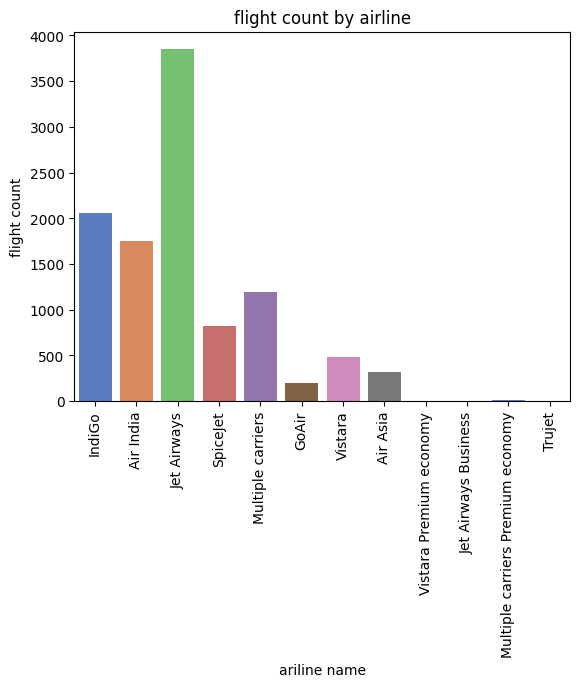

In [149]:
sns.countplot(x="airline" , data= df,palette="muted")
plt.xticks(rotation = 90)
plt.xlabel("ariline name")
plt.ylabel("flight count")
plt.title("flight count by airline")
plt.show()

# Jet Airways has the highest number of flights

/tmp/ipykernel_1448/3544560337.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["source"], palette="viridis")


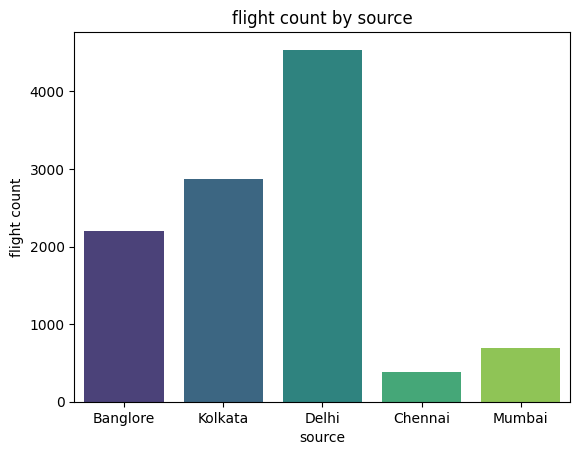

In [150]:
sns.countplot(x=df["source"], palette="viridis")
plt.xlabel("source")
plt.ylabel("flight count")
plt.title("flight count by source")
plt.show()

# Delhi has the highest number of flights as a source.

/tmp/ipykernel_1448/4101229790.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["destination"], palette="coolwarm")


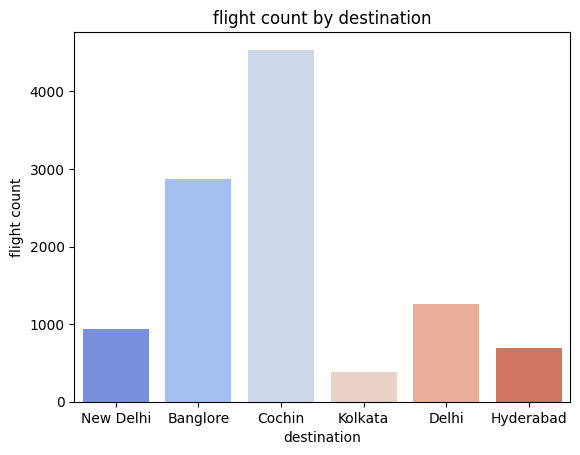

In [151]:
sns.countplot(x=df["destination"], palette="coolwarm")
plt.xlabel("destination")
plt.ylabel("flight count")
plt.title("flight count by destination")
plt.show()

# Cochin has the highest number of flight arrivals

In [152]:
cat_col

['airline', 'source', 'destination', 'route', 'additional_info']

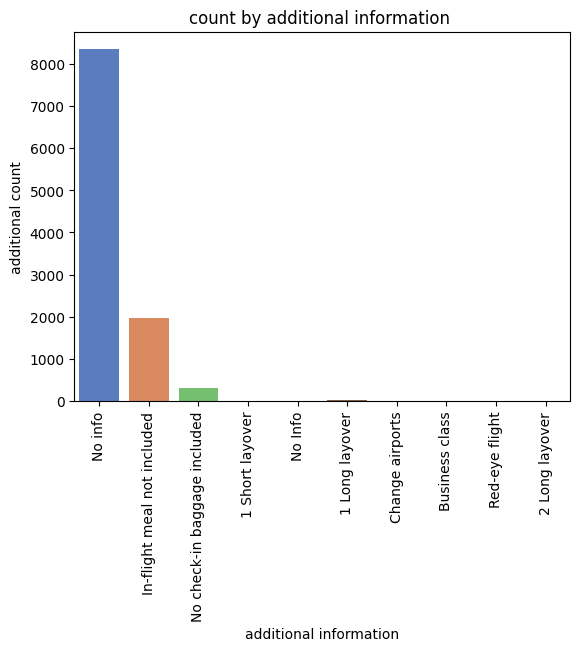

In [153]:
import warnings
warnings.filterwarnings("ignore")

sns.countplot(x=df["additional_info"], palette="muted")
plt.xticks(rotation=90)
plt.xlabel("additional information")
plt.ylabel("additional count")
plt.title("count by additional information ")
plt.show()

In [154]:
num_col

['day_of_journey',
 'month_of_journey',
 'year_of_journey',
 'dep_hour',
 'dep_min',
 'duration_hour',
 'duration_min',
 'total_stops',
 'price',
 'arrival_hour',
 'arrival_min']

In [155]:
df.columns

Index(['airline', 'day_of_journey', 'month_of_journey', 'year_of_journey',
       'source', 'destination', 'route', 'dep_hour', 'dep_min',
       'duration_hour', 'duration_min', 'total_stops', 'additional_info',
       'price', 'arrival_hour', 'arrival_min'],
      dtype='object')

In [156]:
df.groupby(["airline"])["price"].mean().sort_values(ascending=False)

,price
airline,
Jet Airways Business,58358.666667
Jet Airways,11643.923357
Multiple carriers Premium economy,11418.846154
Multiple carriers,10902.678094
Air India,9611.210616
Vistara Premium economy,8962.333333
Vistara,7796.348643
GoAir,5861.056701
IndiGo,5673.682903


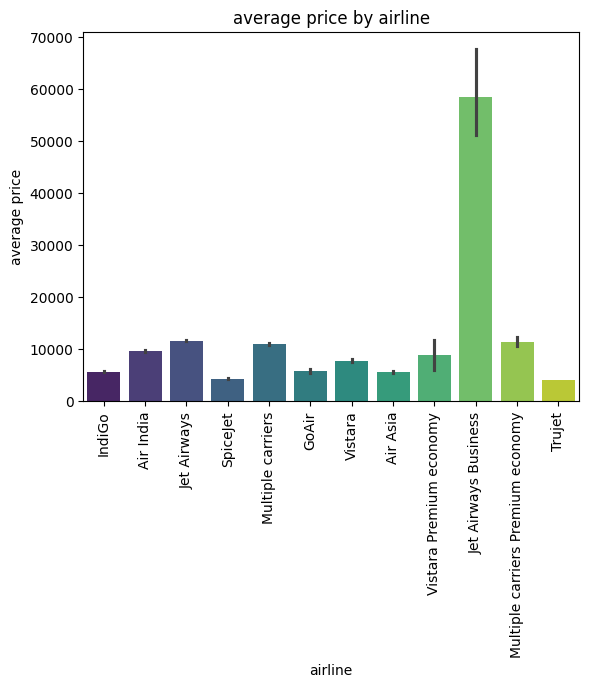

In [157]:
df.groupby(["airline"])["price"].mean().sort_values(ascending=False)
sns.barplot(x="airline", y= "price", data=df, palette="viridis")
plt.xticks(rotation=90)
plt.xlabel("airline")
plt.ylabel("average price")
plt.title("average price by airline")
plt.show()

# Jet Airways Business has the highest average ticket price

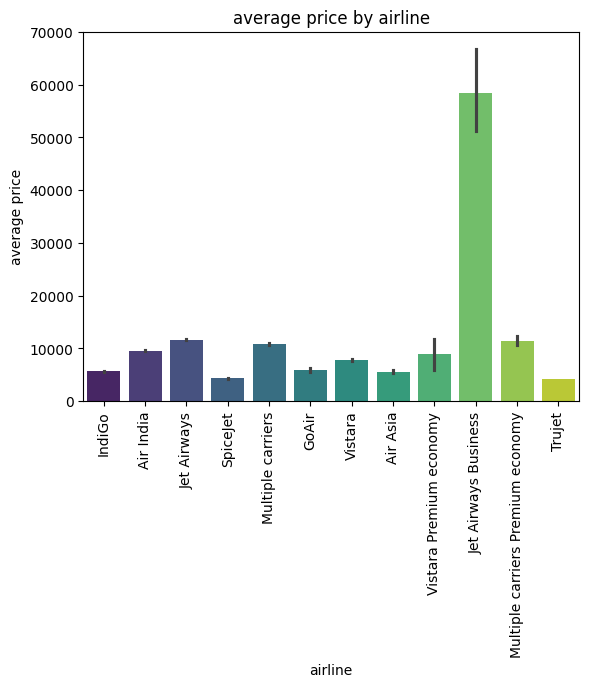

In [158]:
df.groupby(["airline"])["price"].mean().sort_values(ascending=True)
sns.barplot(x="airline", y= "price", data=df, palette="viridis")
plt.xticks(rotation=90)
plt.xlabel("airline")
plt.ylabel("average price")
plt.title("average price by airline")
plt.show()

# Trujet has the lowest average ticket price

In [159]:
df.groupby(["airline"])["price"].mean().sort_values(ascending=True)

,price
airline,
Trujet,4140.000000
SpiceJet,4338.284841
Air Asia,5590.260188
IndiGo,5673.682903
GoAir,5861.056701
Vistara,7796.348643
Vistara Premium economy,8962.333333
Air India,9611.210616
Multiple carriers,10902.678094


In [160]:
df.airline.value_counts().sort_values(ascending=False)

,count
airline,
Jet Airways,3849
IndiGo,2053
Air India,1752
Multiple carriers,1196
SpiceJet,818
Vistara,479
Air Asia,319
GoAir,194
Multiple carriers Premium economy,13


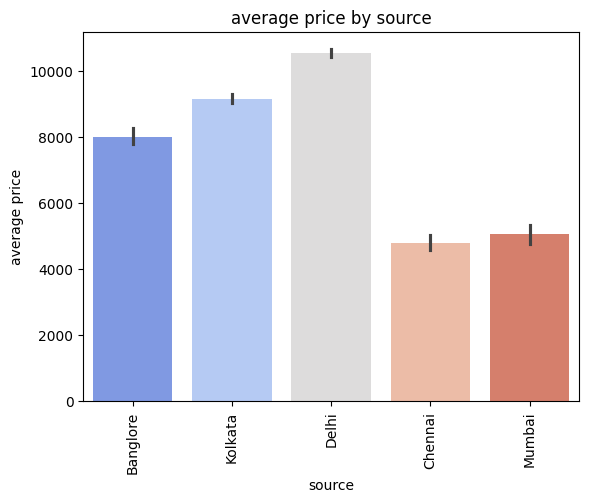

In [161]:
df.groupby(["source"])["price"].mean().sort_values(ascending=False)
sns.barplot(x="source", y="price",data=df, palette="coolwarm")
plt.xticks(rotation=90)
plt.xlabel("source")
plt.ylabel("average price")
plt.title("average price by source")
plt.show()

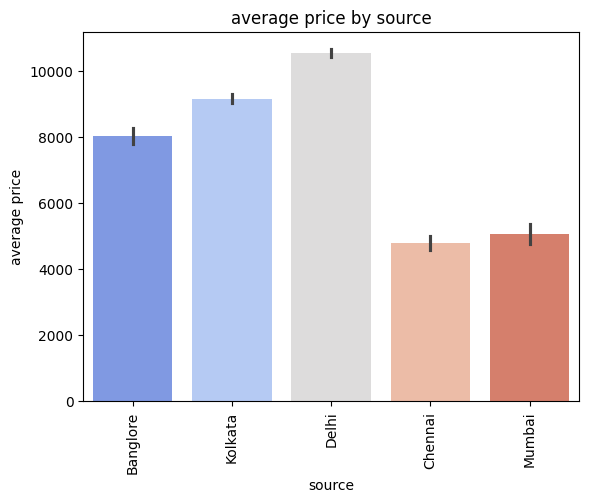

In [162]:
df.groupby(["source"])["price"].mean().sort_values(ascending=True)
sns.barplot(x="source", y="price",data=df, palette="coolwarm")
plt.xticks(rotation=90)
plt.xlabel("source")
plt.ylabel("average price")
plt.title("average price by source")
plt.show()

# Which destination has the most flights

In [163]:
df.destination.value_counts().sort_values(ascending=False)

,count
destination,
Cochin,4537
Banglore,2871
Delhi,1265
New Delhi,932
Hyderabad,697
Kolkata,381


# cochine destination has the most flights

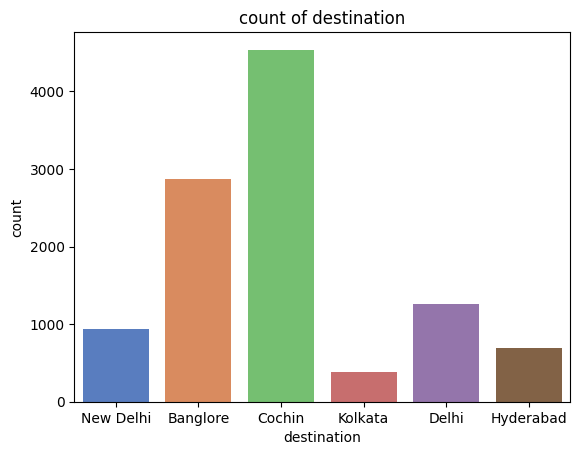

In [164]:
sns.countplot(x="destination", data= df , palette="muted")
plt.xlabel("destination")
plt.ylabel("count")
plt.title("count of destination")
plt.show()

# Which destination has the highest average ticket price
# Which destination has the lowest average ticket price

In [165]:

df.groupby(["destination"])["price"].mean().sort_values(ascending=False)


,price
destination,
New Delhi,11917.716738
Cochin,10539.439057
Banglore,9158.389411
Delhi,5143.918577
Hyderabad,5059.708752
Kolkata,4789.892388


#highest -new delhi

In [166]:
df.groupby(["destination"])["price"].mean().sort_values(ascending=True)

,price
destination,
Kolkata,4789.892388
Hyderabad,5059.708752
Delhi,5143.918577
Banglore,9158.389411
Cochin,10539.439057
New Delhi,11917.716738


# lowest kolkata

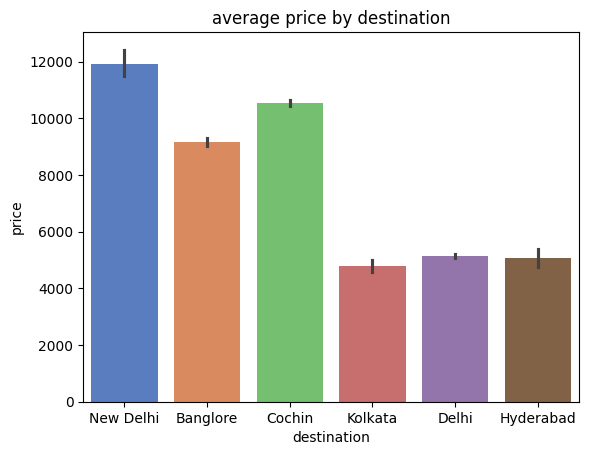

In [167]:
df.groupby(["destination"])["price"].mean().sort_values(ascending=False)
sns.barplot(x="destination", y="price", data= df , palette="muted")
plt.xlabel("destination")
plt.ylabel("price")
plt.title("average price by destination")
plt.show()

In [168]:
df.route.value_counts().sort_values(ascending=False)

,count
route,
DEL → BOM → COK,2376
BLR → DEL,1552
CCU → BOM → BLR,979
CCU → BLR,724
BOM → HYD,621
...,...
BOM → VNS → DEL → HYD,1
BLR → HBX → BOM → NAG → DEL,1
BLR → BOM → IXC → DEL,1


# delhi to cochin

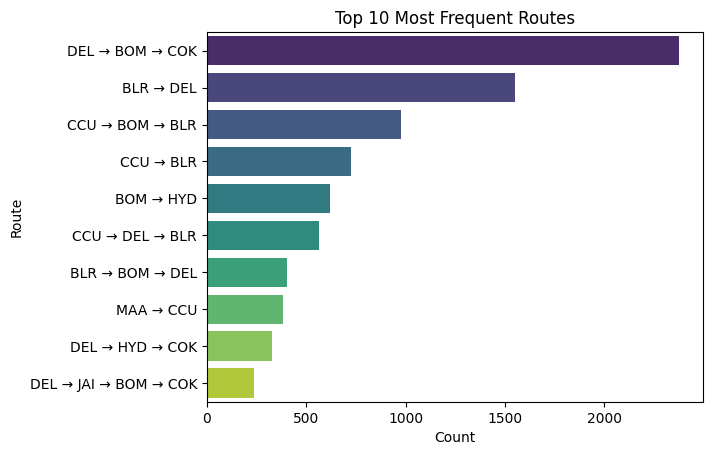

In [173]:
df1 = df["route"].value_counts().head(10)

sns.barplot(x=df1.values, y=df1.index, palette="viridis")

plt.xlabel("Count")
plt.ylabel("Route")
plt.title("Top 10 Most Frequent Routes")
plt.show()

# Most expensive routes

In [174]:
df.groupby(["route"])["price"].mean().sort_values(ascending= False)

,price
route,
BOM → DED → DEL → HYD,24115.000000
BOM → JDH → DEL → HYD,23867.000000
BOM → VNS → DEL → HYD,23528.000000
BOM → UDR → DEL → HYD,22950.000000
BOM → BDQ → DEL → HYD,22792.500000
...,...
CCU → HYD → BLR,4910.018868
MAA → CCU,4789.892388
CCU → BLR,4556.055249


# BOM → DED → DEL → HYD

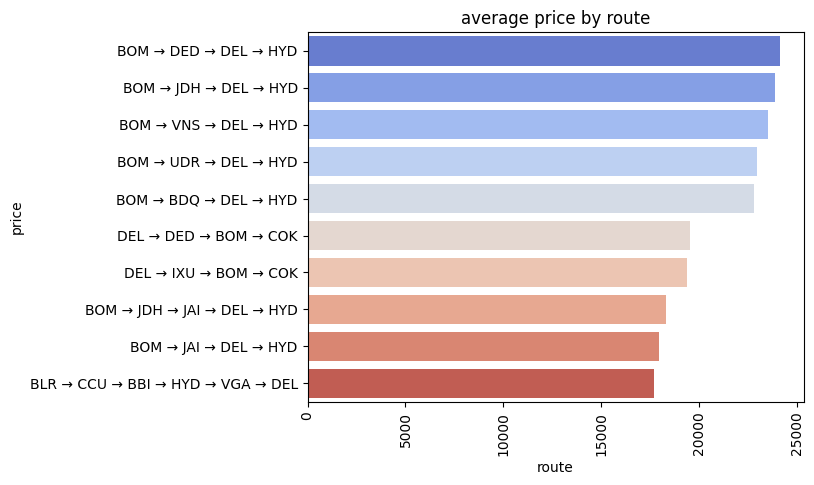

In [178]:
df1=df.groupby(["route"])["price"].mean().sort_values(ascending=False).head(10)
sns. barplot(x=df1.values, y=df1.index , palette="coolwarm")
plt.xticks(rotation=90)
plt.xlabel("route")
plt.ylabel("price")
plt.title("average price by route")
plt.show()


# Cheapest routes  - BLR → CCU → BBI → HYD → VGA → DEL

# Which departure hour has the highest average price?

In [179]:
df.groupby(["dep_hour"])["price"].mean().sort_values(ascending=False)

,price
dep_hour,
3,10474.625000
16,10320.459746
8,10083.322812
18,10035.824324
14,9906.034417
5,9681.992051
20,9670.574501
9,9641.803493
23,9473.770186


# 3 hour

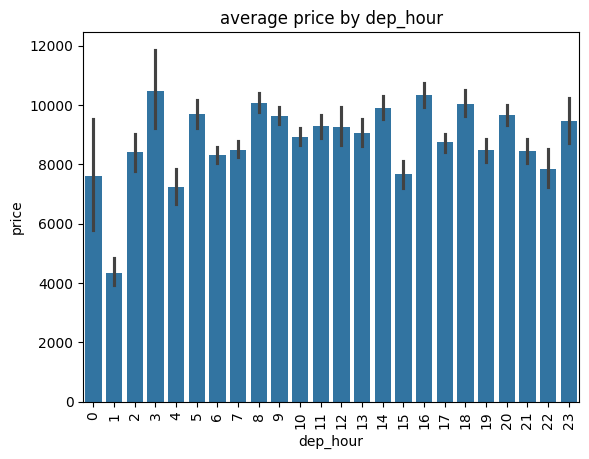

In [180]:
df.groupby(["dep_hour"])["price"].mean().sort_values(ascending=False)
sns. barplot(x="dep_hour", y="price", data= df )
plt.xticks(rotation=90)
plt.xlabel("dep_hour")
plt.ylabel("price")
plt.title("average price by dep_hour")
plt.show()


In [181]:
df


,airline,day_of_journey,month_of_journey,year_of_journey,source,destination,route,dep_hour,dep_min,duration_hour,duration_min,total_stops,additional_info,price,arrival_hour,arrival_min
0,IndiGo,24,3,2019,Banglore,New Delhi,BLR → DEL,22,20,2,50,0,No info,3897,1,10
1,Air India,1,5,2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,5,50,7,25,2,No info,7662,1,15
2,Jet Airways,9,6,2019,Delhi,Cochin,DEL → LKO → BOM → COK,9,25,19,0,2,No info,13882,4,25
3,IndiGo,12,5,2019,Kolkata,Banglore,CCU → NAG → BLR,18,5,5,25,1,No info,6218,11,30
4,IndiGo,1,3,2019,Banglore,New Delhi,BLR → NAG → DEL,16,50,4,45,1,No info,13302,9,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9,4,2019,Kolkata,Banglore,CCU → BLR,19,55,2,30,0,No info,4107,10,25
10679,Air India,27,4,2019,Kolkata,Banglore,CCU → BLR,20,45,2,35,0,No info,4145,11,20
10680,Jet Airways,27,4,2019,Banglore,Delhi,BLR → DEL,8,20,3,0,0,No info,7229,11,20
10681,Vistara,1,3,2019,Banglore,New Delhi,BLR → DEL,11,30,2,40,0,No info,12648,2,10


# Which departure hour has the most flights?

In [182]:
df["dep_hour"].value_counts().sort_values(ascending=False)

,count
dep_hour,
9,916
7,867
8,697
17,695
6,687
20,651
5,629
11,580
19,567


# most flight 9 departure hour
# low flight 3 departure hour

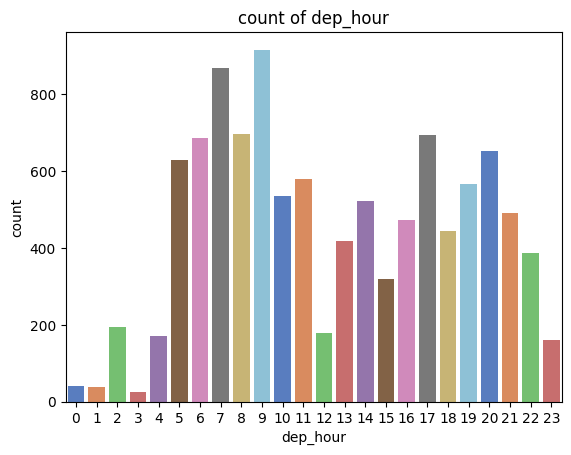

In [185]:
df2= df["dep_hour"].value_counts().sort_values(ascending=False)
sns.countplot(x="dep_hour",data=df,palette="muted")
plt.xlabel("dep_hour")
plt.ylabel("count")
plt.title("count of dep_hour")
plt.show()


# Morning vs afternoon vs evening vs night price comparison

In [ ]:
# using feature engineering

In [310]:
def ctrgy(hour):
    if 5 <= hour < 12:
        return "morning"
    elif 12 <= hour < 17:
        return "afternoon"
    elif 17 <= hour < 21:
        return "evening"
    else:
        return "night"


In [311]:
df["dep_seasons"]= df["dep_hour"].apply(ctrgy)

In [312]:
df.head()

,airline,day_of_journey,month_of_journey,year_of_journey,source,destination,route,dep_hour,dep_min,duration_hour,duration_min,total_stops,additional_info,price,arrival_hour,arrival_min,dep_seasons,total_duration,duration_category
0,IndiGo,24,3,2019,Banglore,New Delhi,BLR → DEL,22,20,2,50,0,No info,3897,1,10,night,140,short duration
1,Air India,1,5,2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,5,50,7,25,2,No info,7662,1,15,morning,470,medium duration
2,Jet Airways,9,6,2019,Delhi,Cochin,DEL → LKO → BOM → COK,9,25,19,0,2,No info,13882,4,25,morning,1165,long duration
3,IndiGo,12,5,2019,Kolkata,Banglore,CCU → NAG → BLR,18,5,5,25,1,No info,6218,11,30,evening,305,medium duration
4,IndiGo,1,3,2019,Banglore,New Delhi,BLR → NAG → DEL,16,50,4,45,1,No info,13302,9,35,afternoon,290,medium duration


In [313]:
df.groupby(["dep_seasons"])["price"].sum().sort_values(ascending=False)

,price
dep_seasons,
morning,45201607
evening,21634510
afternoon,17930887
night,12310102


In [314]:
df.groupby(["dep_seasons"])["price"].mean().sort_values(ascending=False)

,price
dep_seasons,
afternoon,9392.816658
morning,9202.281555
evening,9178.833263
night,8179.469767


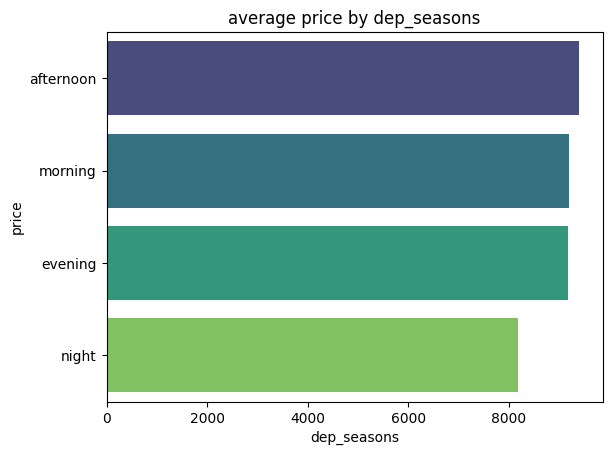

In [315]:
df3 = df.groupby(["dep_seasons"])["price"].mean().sort_values(ascending=False)
sns.barplot(x=df3.values, y=df3.index , palette="viridis")
plt.xlabel("dep_seasons")
plt.ylabel("price")
plt.title("average price by dep_seasons")
plt.show()

# afternoon - hight flight departure
# night - minimum flight departure

In [ ]:
# Does longer flight duration lead to higher prices

In [316]:
df["total_duration"] = df["duration_hour"]*60 + df["duration_min"]

In [317]:
df[["total_duration","price"]].corr()

,total_duration,price
total_duration,1.000000,0.506495
price,0.506495,1.000000


# Flight duration has a moderate positive correlation with ticket price (0.506), indicating that longer flights tend to have higher ticket prices.

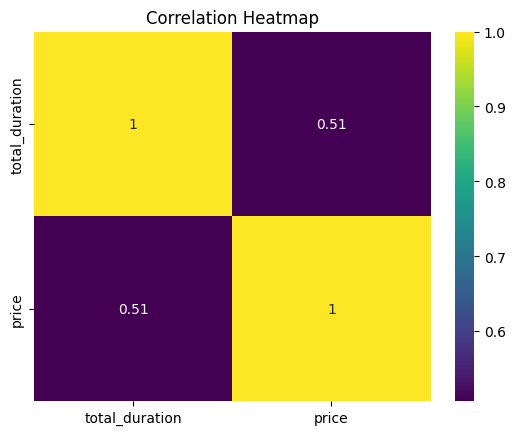

In [318]:
corrrelation = df[["total_duration","price"]].corr()
sns.heatmap(corrrelation, annot=True , cmap="viridis")
plt.title("Correlation Heatmap")
plt.show()

# Which duration range has the highest average price

In [319]:
df.groupby(["dep_seasons"])["price"].mean().sort_values(ascending=False).head(1)

,price
dep_seasons,
afternoon,9392.816658


# afternoon

In [286]:
df.head(5)

,airline,day_of_journey,month_of_journey,year_of_journey,source,destination,route,dep_hour,dep_min,duration_hour,duration_min,total_stops,additional_info,price,arrival_hour,arrival_min,dep_seasons,total_duration,duration_category
0,IndiGo,24,3,2019,Banglore,New Delhi,BLR → DEL,22,20,2,50,0,No info,3897,1,10,night,140,long duration
1,Air India,1,5,2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,5,50,7,25,2,No info,7662,1,15,morning,470,medium duration
2,Jet Airways,9,6,2019,Delhi,Cochin,DEL → LKO → BOM → COK,9,25,19,0,2,No info,13882,4,25,evening,1165,medium duration
3,IndiGo,12,5,2019,Kolkata,Banglore,CCU → NAG → BLR,18,5,5,25,1,No info,6218,11,30,morning,305,long duration
4,IndiGo,1,3,2019,Banglore,New Delhi,BLR → NAG → DEL,16,50,4,45,1,No info,13302,9,35,night,290,long duration


In [320]:
df["total_duration"].value_counts().head(10)

,count
total_duration,
170,550
90,386
175,337
165,337
155,329
180,261
140,238
150,220
160,158


In [321]:
# duration category
def dur(app):
  if 0 <= app < 240:
    return "short duration"
  elif 240 <= app < 600:
    return "medium duration"
  else:
    return "long duration"

In [322]:
df["duration_category"] = df["total_duration"].apply(dur)

In [323]:
df["duration_category"]

,duration_category
0,short duration
1,medium duration
2,long duration
3,medium duration
4,medium duration
5,short duration
6,long duration
7,long duration
8,long duration
9,medium duration


In [324]:
df["duration_category"].value_counts()

,count
duration_category,
long duration,4759
short duration,3524
medium duration,2400


# Which month has the highest average ticket price?

In [325]:
df.groupby(["month_of_journey"])["price"].mean().sort_values(ascending=False)

,price
month_of_journey,
3,10673.205580
5,9127.247548
6,8828.796134
4,5770.847081


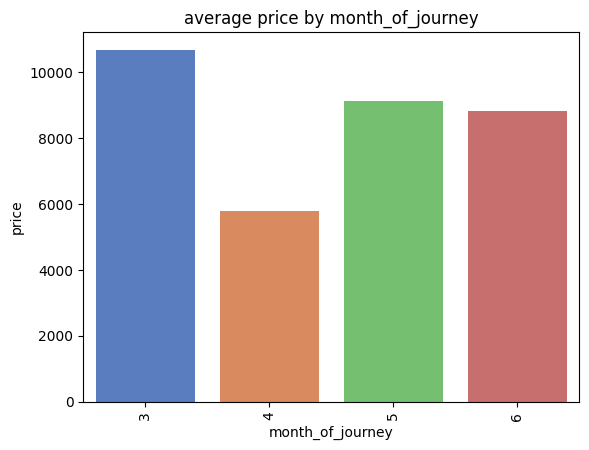

In [326]:
df4 = df.groupby(["month_of_journey"])["price"].mean().sort_values(ascending=False)
sns.barplot(x=df4.index, y=df4.values , palette="muted")
plt.xticks(rotation=90)
plt.xlabel("month_of_journey")
plt.ylabel("price")
plt.title("average price by month_of_journey")
plt.show()

# 3 month

# Which journey day has the highest average price?

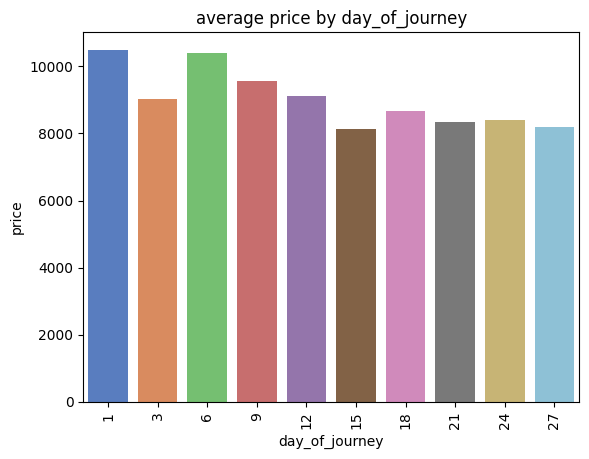

In [294]:
df5 = df.groupby(["day_of_journey"])["price"].mean().sort_values(ascending=False)
sns.barplot(x=df5.index, y=df5.values , palette="muted")
plt.xticks(rotation=90)
plt.xlabel("day_of_journey")
plt.ylabel("price")
plt.title("average price by day_of_journey")
plt.show()

# 1

In [295]:
# Average ticket price

df["price"].mean()

np.float64(9087.064120565385)

In [296]:
# Minimum ticket price
df["price"].min()

1759

In [297]:
# Maximum ticket price
df["price"].max()

79512

<Axes: xlabel='price', ylabel='Density'>

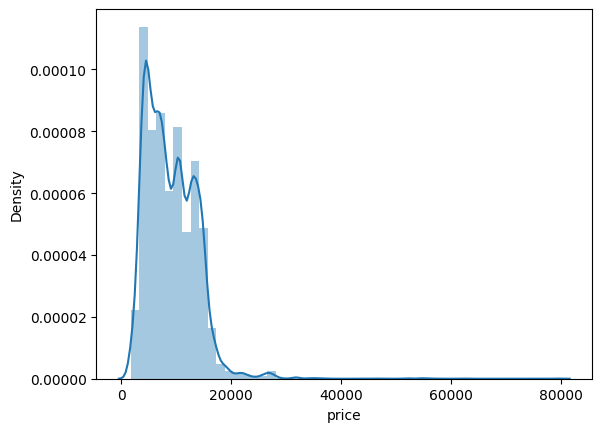

In [298]:
# Price distribution
sns.distplot(df["price"])


In [299]:
# Most expensive flights
df.sort_values(by="price", ascending=False).head(10)


,airline,day_of_journey,month_of_journey,year_of_journey,source,destination,route,dep_hour,dep_min,duration_hour,duration_min,total_stops,additional_info,price,arrival_hour,arrival_min,dep_seasons,total_duration,duration_category
2924,Jet Airways Business,1,3,2019,Banglore,New Delhi,BLR → BOM → DEL,5,45,5,40,1,Business class,79512,11,25,morning,345,medium duration
5372,Jet Airways Business,1,3,2019,Banglore,New Delhi,BLR → BOM → DEL,5,45,6,40,1,Business class,62427,12,25,morning,405,medium duration
10364,Jet Airways Business,1,3,2019,Banglore,New Delhi,BLR → MAA → DEL,9,45,4,40,1,Business class,57209,2,25,night,285,medium duration
5439,Jet Airways,1,3,2019,Banglore,New Delhi,BLR → BOM → DEL,16,55,6,5,1,No info,54826,11,0,morning,415,medium duration
2618,Jet Airways,18,3,2019,Banglore,New Delhi,BLR → BOM → DEL,22,50,6,15,1,No info,54826,5,5,morning,410,medium duration
1478,Jet Airways,18,3,2019,Banglore,New Delhi,BLR → BOM → DEL,18,40,6,5,1,No info,54826,12,45,morning,400,medium duration
9715,Jet Airways Business,6,3,2019,Delhi,Cochin,DEL → ATQ → BOM → COK,20,5,8,20,2,No info,52285,4,25,morning,485,medium duration
657,Jet Airways Business,1,3,2019,Banglore,New Delhi,BLR → BOM → DEL,5,45,5,0,1,No info,52229,10,45,morning,345,medium duration
7351,Jet Airways Business,3,3,2019,Delhi,Cochin,DEL → ATQ → BOM → COK,20,5,8,20,2,No info,46490,4,25,morning,485,medium duration
396,Multiple carriers,1,3,2019,Delhi,Cochin,DEL → BOM → COK,12,50,6,25,1,No info,36983,7,15,morning,410,medium duration


In [241]:
# Cheapest flights

df.sort_values(by= "price", ascending= True).head(10)

,airline,day_of_journey,month_of_journey,year_of_journey,source,destination,route,dep_hour,dep_min,duration_hour,duration_min,total_stops,additional_info,price,arrival_hour,arrival_min,dep_seasons,total_duration,duration_category
10513,SpiceJet,27,3,2019,Mumbai,Hyderabad,BOM → HYD,5,45,1,20,0,No info,1759,7,5,morning,345,medium duration
4066,SpiceJet,21,3,2019,Mumbai,Hyderabad,BOM → HYD,22,45,1,25,0,No info,1759,12,10,evening,1365,long duration
4274,SpiceJet,27,3,2019,Mumbai,Hyderabad,BOM → HYD,22,45,1,25,0,No info,1759,12,10,evening,1365,long duration
4839,SpiceJet,3,4,2019,Mumbai,Hyderabad,BOM → HYD,22,45,1,30,0,No info,1759,12,15,evening,1365,long duration
1513,Jet Airways,27,3,2019,Mumbai,Hyderabad,BOM → HYD,2,55,1,30,0,In-flight meal not included,1840,4,25,night,175,short duration
1718,SpiceJet,24,5,2019,Mumbai,Hyderabad,BOM → HYD,5,45,1,30,0,No check-in baggage included,1965,7,15,morning,345,medium duration
6142,SpiceJet,15,6,2019,Mumbai,Hyderabad,BOM → HYD,13,15,1,30,0,No check-in baggage included,1965,2,45,afternoon,795,long duration
9629,SpiceJet,9,6,2019,Mumbai,Hyderabad,BOM → HYD,22,45,1,30,0,No check-in baggage included,1965,12,15,evening,1365,long duration
4595,SpiceJet,3,5,2019,Mumbai,Hyderabad,BOM → HYD,5,45,1,30,0,No check-in baggage included,1965,7,15,morning,345,medium duration
8775,SpiceJet,24,6,2019,Mumbai,Hyderabad,BOM → HYD,13,15,1,30,0,No check-in baggage included,1965,2,45,afternoon,795,long duration


In [242]:
# Which additional_info category occurs most?
df["additional_info"].value_counts()

,count
additional_info,
No info,8345
In-flight meal not included,1982
No check-in baggage included,320
1 Long layover,19
Change airports,7
Business class,4
No Info,3
1 Short layover,1
Red-eye flight,1


# Which airline has the highest average ticket price?

In [300]:
df.groupby(["airline"])["price"].mean().sort_values(ascending=False).head(10)

,price
airline,
Jet Airways Business,58358.666667
Jet Airways,11643.923357
Multiple carriers Premium economy,11418.846154
Multiple carriers,10902.678094
Air India,9611.210616
Vistara Premium economy,8962.333333
Vistara,7796.348643
GoAir,5861.056701
IndiGo,5673.682903


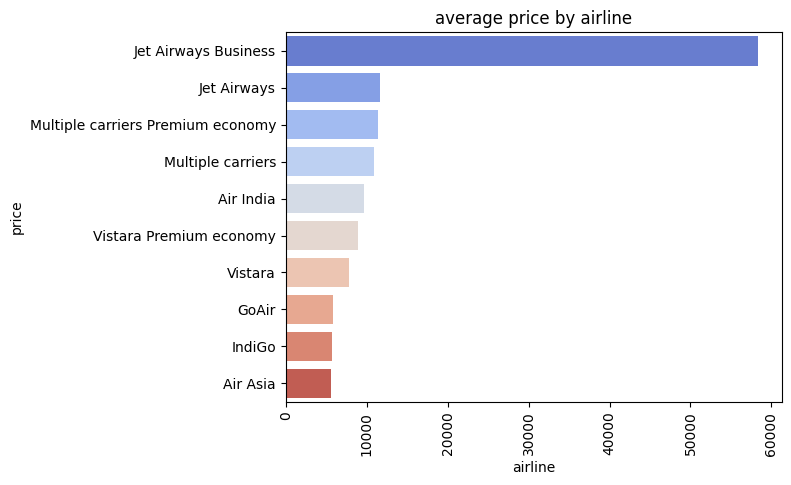

In [301]:
df6 = df.groupby(["airline"])["price"].mean().sort_values(ascending=False).head(10)
sns.barplot(x=df6.values, y=df6.index , palette="coolwarm")
plt.xticks(rotation=90)
plt.xlabel("airline")
plt.ylabel("price")
plt.title("average price by airline")
plt.show()

# Which airline operates the most flight

In [302]:
df["airline"].value_counts().sort_values(ascending=False)

,count
airline,
Jet Airways,3849
IndiGo,2053
Air India,1752
Multiple carriers,1196
SpiceJet,818
Vistara,479
Air Asia,319
GoAir,194
Multiple carriers Premium economy,13


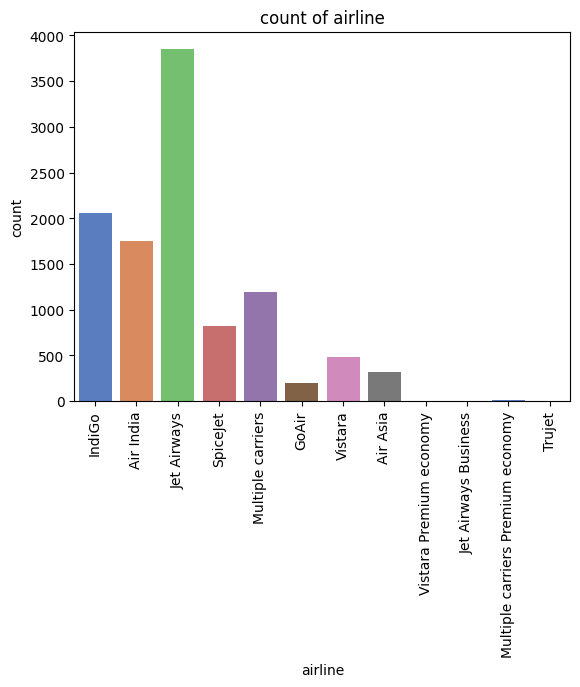

In [303]:
sns.countplot(x="airline", data= df , palette="muted")
plt.xticks(rotation=90)
plt.xlabel("airline")
plt.ylabel("count")
plt.title("count of airline")
plt.show()

# jet airways

# Which source city has the highest average ticket price

In [251]:
df.groupby(["source"])["price"].mean().sort_values(ascending=False)

,price
source,
Delhi,10539.439057
Kolkata,9158.389411
Banglore,8017.464269
Mumbai,5059.708752
Chennai,4789.892388


# delhi

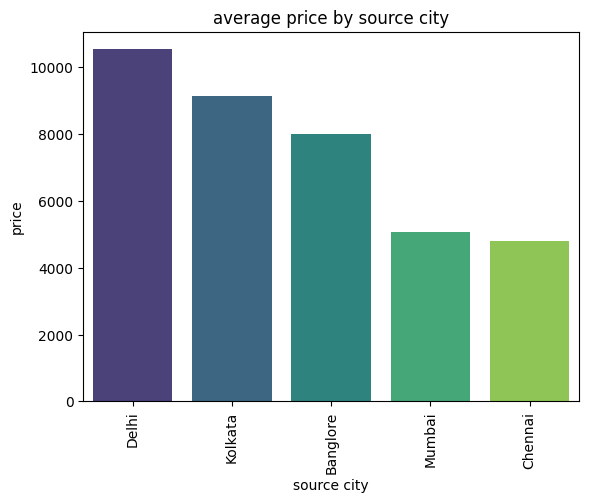

In [252]:
df7= df.groupby(["source"])["price"].mean().sort_values(ascending=False)
sns.barplot(x=df7.index,y=df7.values,palette="viridis")
plt.xticks(rotation=90)
plt.xlabel("source city")
plt.ylabel("price")
plt.title("average price by source city")
plt.show()

# Which destination has the highest average ticket price

In [259]:
df.groupby(["destination"])["price"].mean().sort_values(ascending=False)

,price
destination,
New Delhi,11917.716738
Cochin,10539.439057
Banglore,9158.389411
Delhi,5143.918577
Hyderabad,5059.708752
Kolkata,4789.892388


# new delhi

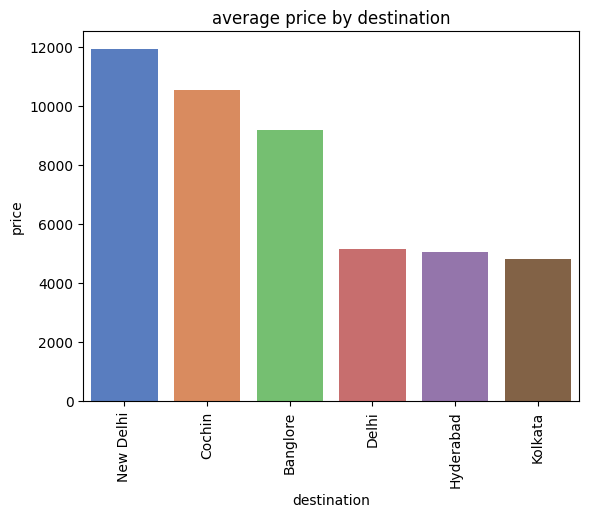

In [255]:
df8 =df.groupby(["destination"])["price"].mean().sort_values(ascending=False)
sns.barplot(x=df8.index, y=df8.values , palette="muted")
plt.xticks(rotation=90)
plt.xlabel("destination")
plt.ylabel("price")
plt.title("average price by destination")
plt.show()

# Which route is the most expensive

In [260]:
df.groupby(["route"])["price"].mean().sort_values(ascending=False)[:10]

,price
route,
BOM → DED → DEL → HYD,24115.000000
BOM → JDH → DEL → HYD,23867.000000
BOM → VNS → DEL → HYD,23528.000000
BOM → UDR → DEL → HYD,22950.000000
BOM → BDQ → DEL → HYD,22792.500000
DEL → DED → BOM → COK,19539.500000
DEL → IXU → BOM → COK,19381.333333
BOM → JDH → JAI → DEL → HYD,18293.000000
BOM → JAI → DEL → HYD,17926.000000


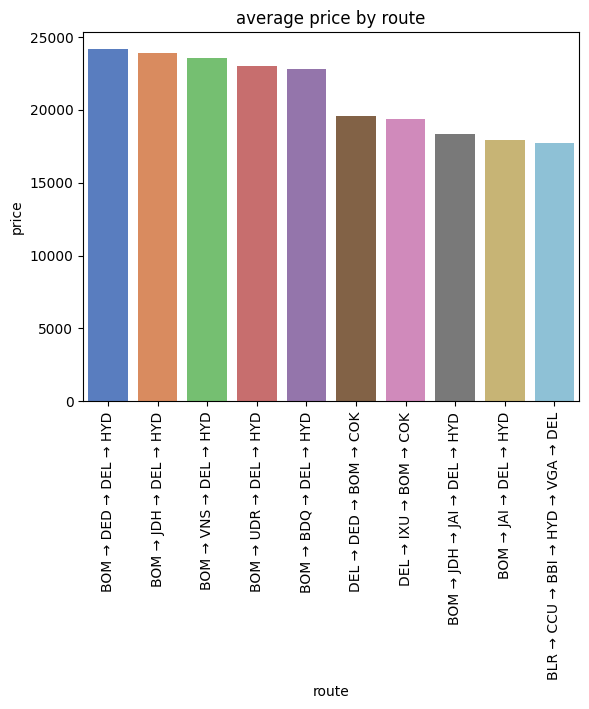

In [261]:
df9 = df.groupby(["route"])["price"].mean().sort_values(ascending=False)[:10]
sns.barplot(x=df9.index, y=df9.values , palette="muted")
plt.xticks(rotation=90)
plt.xlabel("route")
plt.ylabel("price")
plt.title("average price by route")
plt.show()

# BOM → DED → DEL → HYD

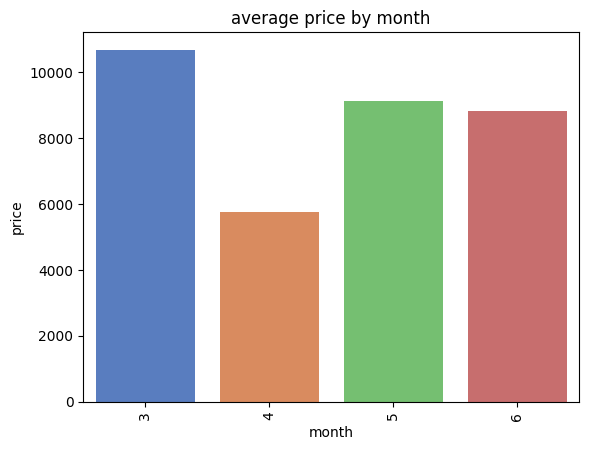

In [262]:
# Which month has the highest average ticket price

df9 = df.groupby(["month_of_journey"])["price"].mean().sort_values(ascending=False)[:10]
sns.barplot(x=df9.index, y=df9.values , palette="muted")
plt.xticks(rotation=90)
plt.xlabel("month")
plt.ylabel("price")
plt.title("average price by month")
plt.show()

# 3rd month


In [304]:
# Does flight duration affect ticket price
df[["total_duration","price"]].corr()


,total_duration,price
total_duration,1.000000,0.507959
price,0.507959,1.000000


# Flight duration has a moderate positive correlation with ticket price (0.508), indicating that longer flights tend to have higher ticket prices.

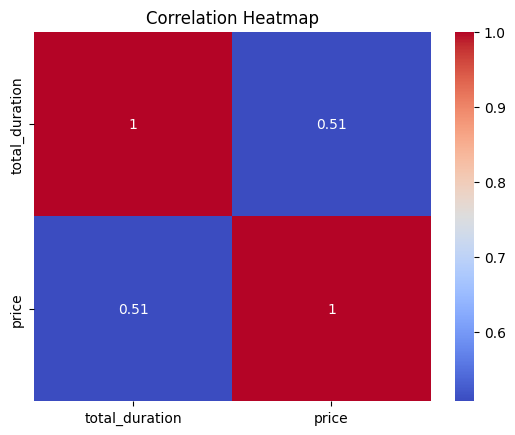

In [305]:
df10 = df[["total_duration","price"]].corr()
sns.heatmap(df10 , annot=True , cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

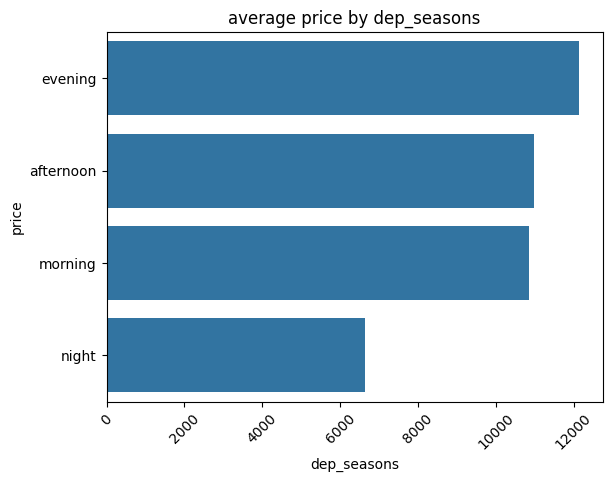

In [306]:
# Which departure time has the highest average ticket price
df11 = df.groupby(["dep_seasons"])["price"].mean().sort_values(ascending=False)
sns.barplot(x=df11.values, y=df11.index )
plt.xticks(rotation=45)
plt.xlabel("dep_seasons")
plt.ylabel("price")
plt.title("average price by dep_seasons")
plt.show()

# evening

In [307]:
# Does the number of stops affect ticket price

df[["total_stops","price"]].corr()

,total_stops,price
total_stops,1.000000,0.603883
price,0.603883,1.000000


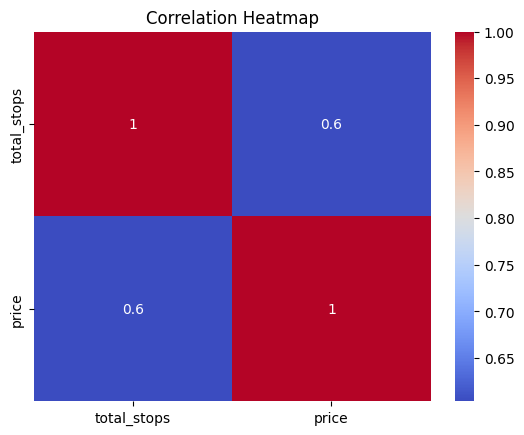

In [308]:
df12 = df[["total_stops","price"]].corr()
sns.heatmap(df12 , annot=True , cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Number of stops has a moderate positive correlation with ticket price (0.604), indicating that flights with more stops tend to have higher ticket prices.

In [273]:
# What are the most expensive flight options
df.sort_values(by="price", ascending= False).head(5)

,airline,day_of_journey,month_of_journey,year_of_journey,source,destination,route,dep_hour,dep_min,duration_hour,duration_min,total_stops,additional_info,price,arrival_hour,arrival_min,dep_seasons,total_duration,duration_category
2924,Jet Airways Business,1,3,2019,Banglore,New Delhi,BLR → BOM → DEL,5,45,5,40,1,Business class,79512,11,25,morning,345,medium duration
5372,Jet Airways Business,1,3,2019,Banglore,New Delhi,BLR → BOM → DEL,5,45,6,40,1,Business class,62427,12,25,morning,345,medium duration
10364,Jet Airways Business,1,3,2019,Banglore,New Delhi,BLR → MAA → DEL,9,45,4,40,1,Business class,57209,2,25,morning,585,medium duration
5439,Jet Airways,1,3,2019,Banglore,New Delhi,BLR → BOM → DEL,16,55,6,5,1,No info,54826,11,0,afternoon,1015,long duration
2618,Jet Airways,18,3,2019,Banglore,New Delhi,BLR → BOM → DEL,22,50,6,15,1,No info,54826,5,5,evening,1370,long duration


# Jet Airways Business = 79512

In [274]:
# What are the cheapest flight options
df.sort_values(by="price", ascending=True)[:5]

,airline,day_of_journey,month_of_journey,year_of_journey,source,destination,route,dep_hour,dep_min,duration_hour,duration_min,total_stops,additional_info,price,arrival_hour,arrival_min,dep_seasons,total_duration,duration_category
10513,SpiceJet,27,3,2019,Mumbai,Hyderabad,BOM → HYD,5,45,1,20,0,No info,1759,7,5,morning,345,medium duration
4066,SpiceJet,21,3,2019,Mumbai,Hyderabad,BOM → HYD,22,45,1,25,0,No info,1759,12,10,evening,1365,long duration
4274,SpiceJet,27,3,2019,Mumbai,Hyderabad,BOM → HYD,22,45,1,25,0,No info,1759,12,10,evening,1365,long duration
4839,SpiceJet,3,4,2019,Mumbai,Hyderabad,BOM → HYD,22,45,1,30,0,No info,1759,12,15,evening,1365,long duration
1513,Jet Airways,27,3,2019,Mumbai,Hyderabad,BOM → HYD,2,55,1,30,0,In-flight meal not included,1840,4,25,night,175,short duration


# SpiceJet = 1759

In [275]:
df.isnull().sum()

,0
airline,0
day_of_journey,0
month_of_journey,0
year_of_journey,0
source,0
destination,0
route,0
dep_hour,0
dep_min,0
duration_hour,0


In [309]:
df.to_csv("Flight_analysis_clean_nootbook.csv",index=False)